In [14]:
import pandas as pd

df_gdp = pd.read_csv('sweden_gdp_monthly.csv', sep=None, engine='python')
df_interest = pd.read_csv('sweden_interest_rate_monthly.csv', sep=None, engine='python')
df_unemployment = pd.read_csv('sweden_unemployment_monthly.csv', sep=None, engine='python')

def clean_dataframe(df, date_col_idx, value_col_idx):
    # Remove BOM character from column names
    df.columns = df.columns.str.replace('\ufeff', '', regex=False)

    # Get the actual (cleaned) column names using their indices
    current_date_col_name = df.columns[date_col_idx]
    current_value_col_name = df.columns[value_col_idx]

    # Convert date column to datetime objects, coercing errors
    df[current_date_col_name] = pd.to_datetime(df[current_date_col_name], format='%Y-%m', errors='coerce')

    # Convert value column to numeric, handling comma as decimal separator
    if df[current_value_col_name].dtype == 'object':
        df[current_value_col_name] = df[current_value_col_name].astype(str).str.replace(',', '.', regex=False)
        df[current_value_col_name] = pd.to_numeric(df[current_value_col_name], errors='coerce')

    return df

# Clean df_gdp and rename columns
df_gdp_cleaned = clean_dataframe(df_gdp.copy(), 0, 1) # Pass indices 0 and 1
df_gdp_cleaned = df_gdp_cleaned.rename(columns={df_gdp_cleaned.columns[0]: 'Date', df_gdp_cleaned.columns[1]: 'GDP_Growth'})
df_gdp_cleaned = df_gdp_cleaned.dropna(subset=['Date', 'GDP_Growth'])

# Clean df_interest and rename columns
df_interest_cleaned = clean_dataframe(df_interest.copy(), 0, 1) # Pass indices 0 and 1
df_interest_cleaned = df_interest_cleaned.rename(columns={df_interest_cleaned.columns[0]: 'Date', df_interest_cleaned.columns[1]: 'Interest_Rate'})

# Clean df_unemployment and rename columns
df_unemployment_cleaned = clean_dataframe(df_unemployment.copy(), 0, 1) # Pass indices 0 and 1
df_unemployment_cleaned = df_unemployment_cleaned.rename(columns={df_unemployment_cleaned.columns[0]: 'Date', df_unemployment_cleaned.columns[1]: 'Unemployment_Rate'})

print("Cleaned df_gdp head:")
print(df_gdp_cleaned.head())
print("\nCleaned df_interest head:")
print(df_interest_cleaned.head())
print("\nCleaned df_unemployment head:")
print(df_unemployment_cleaned.head())

Cleaned df_gdp head:
        Date  GDP_Growth
1 2000-02-01         1.8
2 2000-03-01         0.5
3 2000-04-01         0.0
4 2000-05-01         2.8
5 2000-06-01         0.5

Cleaned df_interest head:
        Date  Interest_Rate
0 1990-01-01           11.4
1 1990-02-01           13.0
2 1990-03-01           13.5
3 1990-04-01           12.9
4 1990-05-01           12.0

Cleaned df_unemployment head:
        Date  Unemployment_Rate
0 1983-01-01                3.4
1 1983-02-01                3.7
2 1983-03-01                3.7
3 1983-04-01                3.4
4 1983-05-01                3.7


In [15]:
df_merged = df_gdp_cleaned.merge(df_interest_cleaned, on='Date', how='outer').merge(df_unemployment_cleaned, on='Date', how='outer')
display(df_merged.head())

,Date,GDP_Growth,Interest_Rate,Unemployment_Rate
0,1983-01-01,NaN,NaN,3.4
1,1983-02-01,NaN,NaN,3.7
2,1983-03-01,NaN,NaN,3.7
3,1983-04-01,NaN,NaN,3.4
4,1983-05-01,NaN,NaN,3.7


In [16]:
numerical_cols = ['GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']
covariance_matrix = df_merged[numerical_cols].cov()
print("Covariance Matrix:")
print(covariance_matrix)

Covariance Matrix:
                   GDP_Growth  Interest_Rate  Unemployment_Rate
GDP_Growth           1.702954      -0.084034           0.041250
Interest_Rate       -0.084034      26.399865          -2.749306
Unemployment_Rate    0.041250      -2.749306           5.631566


In [17]:
mean_vector = df_merged[numerical_cols].mean()
print("Mean Vector:")
print(mean_vector)

Mean Vector:
GDP_Growth           0.169775
Interest_Rate        3.521940
Unemployment_Rate    6.583915
dtype: float64


In [18]:
from scipy.stats import multivariate_normal
mvn = multivariate_normal(mean=mean_vector, cov=covariance_matrix)


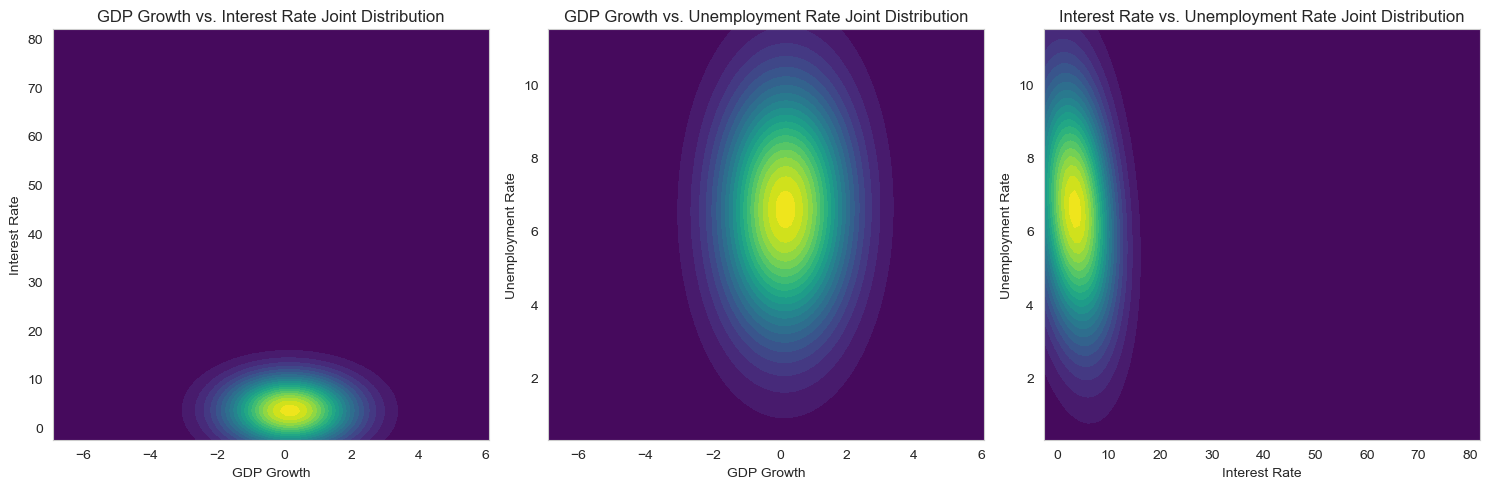

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Define appropriate ranges for each variable
gdp_range = np.linspace(df_merged['GDP_Growth'].min() - 1, df_merged['GDP_Growth'].max() + 1, 100)
interest_range = np.linspace(df_merged['Interest_Rate'].min() - 2, df_merged['Interest_Rate'].max() + 2, 100)
unemployment_range = np.linspace(df_merged['Unemployment_Rate'].min() - 1, df_merged['Unemployment_Rate'].max() + 1, 100)

plt.figure(figsize=(15, 5))

# 1. GDP_Growth vs. Interest_Rate
plt.subplot(1, 3, 1)
X, Y = np.meshgrid(gdp_range, interest_range)
positions = np.array([X.ravel(), Y.ravel(), np.full(X.size, mean_vector['Unemployment_Rate'])]).T
Z = mvn.pdf(positions).reshape(X.shape)
plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.xlabel('GDP Growth')
plt.ylabel('Interest Rate')
plt.title('GDP Growth vs. Interest Rate Joint Distribution')

# 2. GDP_Growth vs. Unemployment_Rate
plt.subplot(1, 3, 2)
X, Y = np.meshgrid(gdp_range, unemployment_range)
positions = np.array([X.ravel(), np.full(X.size, mean_vector['Interest_Rate']), Y.ravel()]).T
Z = mvn.pdf(positions).reshape(X.shape)
plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.xlabel('GDP Growth')
plt.ylabel('Unemployment Rate')
plt.title('GDP Growth vs. Unemployment Rate Joint Distribution')

# 3. Interest_Rate vs. Unemployment_Rate
plt.subplot(1, 3, 3)
X, Y = np.meshgrid(interest_range, unemployment_range)
positions = np.array([np.full(X.size, mean_vector['GDP_Growth']), X.ravel(), Y.ravel()]).T
Z = mvn.pdf(positions).reshape(X.shape)
plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.title('Interest Rate vs. Unemployment Rate Joint Distribution')

plt.tight_layout()
plt.show()

In [20]:
df_pds = pd.read_csv('company_pds_with_sectors.csv', sep=None, engine='python')

# Remove BOM character from column names
df_pds.columns = df_pds.columns.str.replace('\ufeff', '', regex=False)

# Convert 'Date' column to datetime with YYYY-MM format (matches macro data format)
if 'Date' in df_pds.columns:
    df_pds['Date'] = pd.to_datetime(df_pds['Date'], format='%Y-%m')
else:
    # Fallback: if no 'Date' column, use the first column
    date_col_name = df_pds.columns[0]
    df_pds[date_col_name] = pd.to_datetime(df_pds[date_col_name], format='%Y-%m')
    df_pds = df_pds.rename(columns={date_col_name: 'Date'})

print("Columns in df_pds:", df_pds.columns.tolist())
print("\nFirst few rows of df_pds:")
display(df_pds.head())

print("\nBefore merge - PD data shape:", df_pds.shape)
print("Before merge - Macro data shape:", df_merged.shape)

Columns in df_pds: ['Company_number', 'Sector', 'Date', '1_month', '3_month', '6_month', '12_month', '24_month', '36_month', '60_month']

First few rows of df_pds:


,Company_number,Sector,Date,1_month,3_month,6_month,12_month,24_month,36_month,60_month
0,31580,Technology & Software,1991-10-01,0.000044,0.000227,0.000869,0.003861,0.014526,0.026535,0.046737
1,31580,Technology & Software,1991-11-01,0.000031,0.000159,0.000607,0.002738,0.010858,0.020889,0.039702
2,31580,Technology & Software,1991-12-01,0.000012,0.000064,0.000267,0.001399,0.006996,0.015843,0.036760
3,31580,Technology & Software,1992-01-01,0.000020,0.000100,0.000370,0.001655,0.007073,0.014951,0.032735
4,31580,Technology & Software,1992-02-01,0.000014,0.000070,0.000271,0.001291,0.005915,0.012918,0.029079



Before merge - PD data shape: (174167, 10)
Before merge - Macro data shape: (517, 4)


# Task
To proceed with the plan, the next step is to merge the `df_pds` DataFrame, which contains company Probability of Defaults (PDs), with the `df_merged` DataFrame, which contains macroeconomic indicators (GDP_Growth, Interest_Rate, and Unemployment_Rate). This merge will be performed on the 'Date' column to combine these datasets.

After merging, we will inspect the resulting DataFrame to ensure the merge was successful and to understand the combined data structure. This will lay the foundation for identifying key variables and performing the sensitivity analysis.

To achieve this, I will perform the following actions:
1. Merge `df_pds` and `df_merged` on the 'Date' column using an inner join to ensure that only dates present in both DataFrames are included.
2. Display the head of the newly merged DataFrame (`df_final`).
3. Print the shape and information of `df_final` to verify the merge and check data types and non-null counts.

## Merge PDs Data with Macroeconomic Data

### Subtask:
Merge the prepared `df_pds` DataFrame with the `df_merged` DataFrame on the 'Date' column to combine company PDs with macroeconomic indicators. Then, inspect the resulting merged DataFrame.


**Reasoning**:
To merge the two DataFrames as instructed, I will perform an inner join on the 'Date' column between `df_pds` and `df_merged` and store the result in `df_final`. Afterwards, I will display the head, shape, and info of the merged DataFrame to inspect its structure and content.



In [21]:
# Merge PDs with macroeconomic data
# Both datasets now have YYYY-MM date format and will merge properly
df_final = pd.merge(df_pds, df_merged, on='Date', how='inner')

print("\nAfter merge - Final data shape:", df_final.shape)
print(f"Retained {df_final.shape[0]} out of {df_pds.shape[0]} PD datapoints ({100*df_final.shape[0]/df_pds.shape[0]:.1f}%)")

print("\nFirst few rows of the merged DataFrame (df_final):")
display(df_final.head())

print("\nShape of df_final:")
print(df_final.shape)

print("\nInfo of df_final:")
df_final.info()


After merge - Final data shape: (174167, 13)
Retained 174167 out of 174167 PD datapoints (100.0%)

First few rows of the merged DataFrame (df_final):


,Company_number,Sector,Date,1_month,3_month,6_month,12_month,24_month,36_month,60_month,GDP_Growth,Interest_Rate,Unemployment_Rate
0,31580,Technology & Software,1991-10-01,0.000044,0.000227,0.000869,0.003861,0.014526,0.026535,0.046737,NaN,10.5,3.7
1,31580,Technology & Software,1991-11-01,0.000031,0.000159,0.000607,0.002738,0.010858,0.020889,0.039702,NaN,10.7,3.8
2,31580,Technology & Software,1991-12-01,0.000012,0.000064,0.000267,0.001399,0.006996,0.015843,0.036760,NaN,14.6,4.1
3,31580,Technology & Software,1992-01-01,0.000020,0.000100,0.000370,0.001655,0.007073,0.014951,0.032735,NaN,13.0,4.3
4,31580,Technology & Software,1992-02-01,0.000014,0.000070,0.000271,0.001291,0.005915,0.012918,0.029079,NaN,12.0,4.6



Shape of df_final:
(174167, 13)

Info of df_final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174167 entries, 0 to 174166
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Company_number     174167 non-null  int64         
 1   Sector             174167 non-null  object        
 2   Date               174167 non-null  datetime64[ns]
 3   1_month            174167 non-null  float64       
 4   3_month            174167 non-null  float64       
 5   6_month            174167 non-null  float64       
 6   12_month           174167 non-null  float64       
 7   24_month           174167 non-null  float64       
 8   36_month           174167 non-null  float64       
 9   60_month           174167 non-null  float64       
 10  GDP_Growth         158545 non-null  float64       
 11  Interest_Rate      174167 non-null  float64       
 12  Unemployment_Rate  174167 non-null  float64     

**Reasoning**:
The previous step successfully merged the dataframes. Before proceeding with the sensitivity analysis using linear regression, it is crucial to handle missing values, particularly in the macroeconomic indicators as indicated by the `df_final.info()` output for 'GDP_Growth'. Removing rows with NaN values in the macroeconomic columns will ensure that the subsequent regression analysis is performed on complete data, preventing errors and ensuring valid results.



In [22]:
macro_cols = ['GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']
df_final_cleaned = df_final.dropna(subset=macro_cols).copy()

print("Shape of df_final before dropping NaNs:", df_final.shape)
print("Shape of df_final after dropping NaNs:", df_final_cleaned.shape)
print("\nInfo of df_final_cleaned after handling NaNs:")
df_final_cleaned.info()

Shape of df_final before dropping NaNs: (174167, 13)
Shape of df_final after dropping NaNs: (158545, 13)

Info of df_final_cleaned after handling NaNs:
<class 'pandas.core.frame.DataFrame'>
Index: 158545 entries, 100 to 174166
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Company_number     158545 non-null  int64         
 1   Sector             158545 non-null  object        
 2   Date               158545 non-null  datetime64[ns]
 3   1_month            158545 non-null  float64       
 4   3_month            158545 non-null  float64       
 5   6_month            158545 non-null  float64       
 6   12_month           158545 non-null  float64       
 7   24_month           158545 non-null  float64       
 8   36_month           158545 non-null  float64       
 9   60_month           158545 non-null  float64       
 10  GDP_Growth         158545 non-null  float64       
 11  Interes

**Reasoning**:
To prepare for the sensitivity analysis, I will explicitly define the dependent variables (PD maturity columns), independent variables (macroeconomic indicators), and the categorical variable (sector column) based on the task description and the current state of `df_final_cleaned`. This clear identification is essential for setting up the linear regression models correctly.



In [23]:
pd_maturity_cols = ['1_month', '3_month', '6_month', '12_month', '24_month', '36_month', '60_month']
macro_cols = ['GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']
sector_col = 'Sector'

print("Dependent variables (PD Maturity Columns):", pd_maturity_cols)
print("Independent variables (Macroeconomic Indicators):", macro_cols)
print("Categorical variable (Sector Column):", sector_col)

# Create lagged PD columns (t-1) for each company
# Sort by company and date to ensure correct lagging
df_final_cleaned = df_final_cleaned.sort_values(['Company_number', 'Date'])

for pd_col in pd_maturity_cols:
    # Create lagged column (previous time period) per company
    df_final_cleaned[f'{pd_col}_t1'] = df_final_cleaned.groupby('Company_number')[pd_col].shift(1)

# Drop rows where lagged values are NaN (first observation for each company)
df_final_cleaned = df_final_cleaned.dropna(subset=[f'{pd_col}_t1' for pd_col in pd_maturity_cols])

print(f"\nAfter creating lagged PD columns and dropping NaNs: {df_final_cleaned.shape}")
print(f"Lagged columns created: {[f'{col}_t1' for col in pd_maturity_cols]}")

Dependent variables (PD Maturity Columns): ['1_month', '3_month', '6_month', '12_month', '24_month', '36_month', '60_month']
Independent variables (Macroeconomic Indicators): ['GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']
Categorical variable (Sector Column): Sector

After creating lagged PD columns and dropping NaNs: (157002, 20)
Lagged columns created: ['1_month_t1', '3_month_t1', '6_month_t1', '12_month_t1', '24_month_t1', '36_month_t1', '60_month_t1']


**Reasoning**:
To calculate the sensitivity of each PD maturity to macroeconomic factors for each sector, I will iterate through each unique sector and each PD maturity column. For each combination, I will perform a linear regression using `statsmodels.formula.api.ols` to model the PD maturity as a function of the macroeconomic indicators, storing the regression coefficients (sensitivities) in a list. Finally, I will convert this list into a structured DataFrame for easy analysis.



In [24]:
import statsmodels.api as sm

def calculate_logit(p):
    """
    Computes the log-odds (logit) of a probability.
    Clips values to avoid log(0) or division by zero.
    """
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return np.log(p / (1 - p))


sensitivities_data = []

for sector in df_final_cleaned[sector_col].unique():
    sector_df = df_final_cleaned[df_final_cleaned[sector_col] == sector].copy()
    
    print(f"\nProcessing sector: {sector} (n={len(sector_df)})")

    for pd_col in pd_maturity_cols:
        pdzero_col = f'{pd_col}_t1'  # Lagged PD column (t-1)
        
        try:
            # Step 1: Transform the Data - Calculate the 'Change in Logit'
            sector_df['logit_pd'] = calculate_logit(sector_df[pd_col])
            sector_df['logit_pd_zero'] = calculate_logit(sector_df[pdzero_col])
            
            # This delta is what the Macro factors actually explain
            sector_df['delta_logit'] = sector_df['logit_pd'] - sector_df['logit_pd_zero']
            
            # Step 2: Prepare Regression Variables
            y = sector_df['delta_logit']
            X = sector_df[macro_cols]
            
            # Add a constant (intercept) to capture any systematic trend
            X = sm.add_constant(X)
            
            # Drop any remaining NaN values
            valid_idx = ~(y.isna() | X.isna().any(axis=1))
            y = y[valid_idx]
            X = X[valid_idx]
            
            if len(y) < 10:  # Need minimum observations
                print(f"  Skipping {pd_col}: insufficient data (n={len(y)})")
                continue
            
            # Step 3: Run the OLS Regression
            model = sm.OLS(y, X).fit()
            
            # Step 4: Store the Sensitivities
            result = {
                'Sector': sector,
                'PD_Horizon': pd_col,
                'Intercept': model.params['const'],
                'N_observations': len(y),
                'R_squared': model.rsquared
            }
            
            # Add sensitivities for each macroeconomic variable
            for col in macro_cols:
                result[col] = model.params[col]
            
            sensitivities_data.append(result)
            print(f"  ✓ {pd_col}: R²={model.rsquared:.3f}, N={len(y)}")

        except Exception as e:
            print(f"  ✗ Could not fit model for {pd_col}: {e}")

df_sensitivities = pd.DataFrame(sensitivities_data)
print("\n" + "="*80)
print("SENSITIVITY ANALYSIS RESULTS")
print("="*80)
display(df_sensitivities)


Processing sector: Technology & Software (n=33064)
  ✓ 1_month: R²=0.007, N=33064
  ✓ 3_month: R²=0.006, N=33064
  ✓ 6_month: R²=0.005, N=33064
  ✓ 12_month: R²=0.003, N=33064
  ✓ 24_month: R²=0.001, N=33064
  ✓ 36_month: R²=0.001, N=33064
  ✓ 60_month: R²=0.000, N=33064

Processing sector: Industrial & Manufacturing (n=23890)
  ✓ 1_month: R²=0.014, N=23890
  ✓ 3_month: R²=0.015, N=23890
  ✓ 6_month: R²=0.013, N=23890
  ✓ 12_month: R²=0.010, N=23890
  ✓ 24_month: R²=0.006, N=23890
  ✓ 36_month: R²=0.004, N=23890
  ✓ 60_month: R²=0.003, N=23890

Processing sector: Energy & Resources (n=10154)
  ✓ 1_month: R²=0.005, N=10154
  ✓ 3_month: R²=0.004, N=10154
  ✓ 6_month: R²=0.004, N=10154
  ✓ 12_month: R²=0.003, N=10154
  ✓ 24_month: R²=0.002, N=10154
  ✓ 36_month: R²=0.001, N=10154
  ✓ 60_month: R²=0.001, N=10154

Processing sector: Consumer Goods & Retail (n=14010)
  ✓ 1_month: R²=0.010, N=14010
  ✓ 3_month: R²=0.010, N=14010
  ✓ 6_month: R²=0.009, N=14010
  ✓ 12_month: R²=0.006, N=14010


,Sector,PD_Horizon,Intercept,N_observations,R_squared,GDP_Growth,Interest_Rate,Unemployment_Rate
0,Technology & Software,1_month,0.395626,33064,0.006615,-0.016031,-0.005592,-0.049942
1,Technology & Software,3_month,0.357546,33064,0.006278,-0.013981,-0.005251,-0.045085
2,Technology & Software,6_month,0.297352,33064,0.005236,-0.011438,-0.004208,-0.037410
3,Technology & Software,12_month,0.203236,33064,0.003351,-0.008310,-0.002689,-0.025349
4,Technology & Software,24_month,0.101434,33064,0.001369,-0.004463,-0.000780,-0.012427
...,...,...,...,...,...,...,...,...
79,Unassigned,6_month,0.320854,111,0.054083,0.042208,-0.024845,-0.040549
80,Unassigned,12_month,0.257982,111,0.058273,0.040668,-0.020616,-0.032734
81,Unassigned,24_month,0.182447,111,0.064910,0.037556,-0.015387,-0.023346
82,Unassigned,36_month,0.141157,111,0.069925,0.034774,-0.012371,-0.018223


In [25]:
# Analysis of 1-Year PD Sensitivities and Default Events

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

## 1-Year PD Analysis: Focused Results

This section analyzes the 12-month (1-year) probability of default, which is typically the most important horizon for credit risk management.

In [26]:
# Extract 1-Year PD Results
df_1yr = df_sensitivities[df_sensitivities['PD_Horizon'] == '12_month'].copy()

print("="*80)
print("1-YEAR PD SENSITIVITY ANALYSIS")
print("="*80)
print("\n📊 Regression Results: 12-Month Probability of Default\n")
print("Model: Δ logit(PD_12m) = α + β₁·GDP_Growth + β₂·Interest_Rate + β₃·Unemployment_Rate\n")
print(df_1yr[['Sector', 'GDP_Growth', 'Interest_Rate', 'Unemployment_Rate', 'R_squared', 'N_observations']].to_string(index=False))

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("\n✓ Expected Signs:")
print("  • GDP_Growth: NEGATIVE (economic growth → lower default risk)")
print("  • Interest_Rate: POSITIVE (higher rates → higher default risk)")
print("  • Unemployment_Rate: POSITIVE (higher unemployment → higher default risk)")

# Count sign matches
correct_gdp = (df_1yr['GDP_Growth'] < 0).sum()
correct_interest = (df_1yr['Interest_Rate'] > 0).sum()
correct_unemp = (df_1yr['Unemployment_Rate'] > 0).sum()
total_sectors = len(df_1yr)

print(f"\n✓ Sign Consistency Check:")
print(f"  • GDP_Growth: {correct_gdp}/{total_sectors} sectors have expected negative sign ({100*correct_gdp/total_sectors:.0f}%)")
print(f"  • Interest_Rate: {correct_interest}/{total_sectors} sectors have expected positive sign ({100*correct_interest/total_sectors:.0f}%)")
print(f"  • Unemployment_Rate: {correct_unemp}/{total_sectors} sectors have expected positive sign ({100*correct_unemp/total_sectors:.0f}%)")

1-YEAR PD SENSITIVITY ANALYSIS

📊 Regression Results: 12-Month Probability of Default

Model: Δ logit(PD_12m) = α + β₁·GDP_Growth + β₂·Interest_Rate + β₃·Unemployment_Rate

                            Sector  GDP_Growth  Interest_Rate  Unemployment_Rate  R_squared  N_observations
             Technology & Software   -0.008310      -0.002689          -0.025349   0.003351           33064
        Industrial & Manufacturing   -0.015777      -0.004978          -0.033165   0.009941           23890
                Energy & Resources   -0.012058       0.007285          -0.014842   0.002741           10154
           Consumer Goods & Retail   -0.011184      -0.005512          -0.026593   0.005941           14010
            Real Estate & Property   -0.021724      -0.007635          -0.040634   0.011186           11486
        Telecommunications & Media   -0.012326      -0.001767          -0.027919   0.005029            6413
                Financial Services   -0.020959      -0.005949          

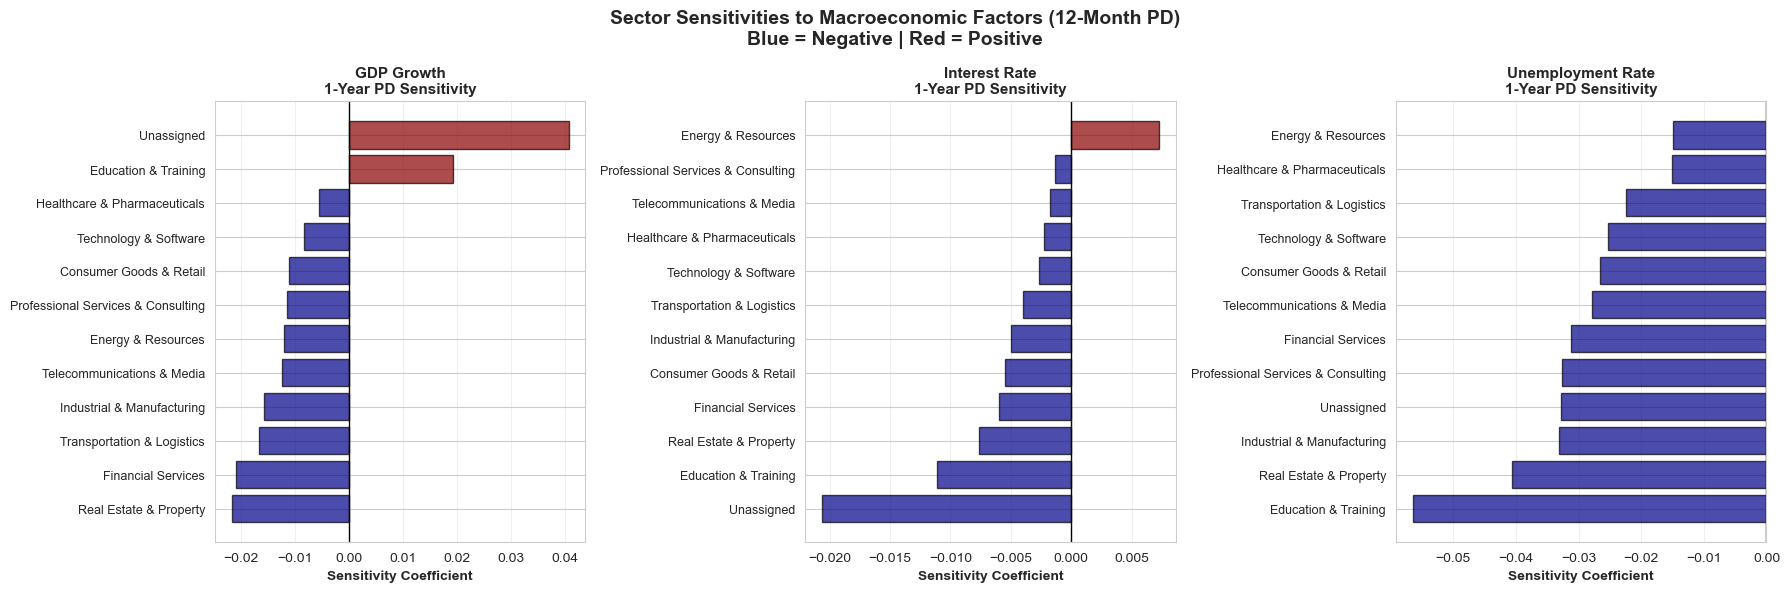

In [27]:
# Visualize 1-Year PD Sensitivities by Sector

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sort by absolute sensitivity
factors_data = [
    ('GDP_Growth', 'GDP Growth', 'Blues_r'),
    ('Interest_Rate', 'Interest Rate', 'Reds'),
    ('Unemployment_Rate', 'Unemployment Rate', 'Oranges')
]

for idx, (factor, label, cmap) in enumerate(factors_data):
    sorted_data = df_1yr.sort_values(factor)
    
    colors = ['darkblue' if x < 0 else 'darkred' for x in sorted_data[factor]]
    
    axes[idx].barh(range(len(sorted_data)), sorted_data[factor], color=colors, alpha=0.7, edgecolor='black')
    axes[idx].set_yticks(range(len(sorted_data)))
    axes[idx].set_yticklabels(sorted_data['Sector'], fontsize=9)
    axes[idx].set_xlabel('Sensitivity Coefficient', fontsize=10, fontweight='bold')
    axes[idx].set_title(f'{label}\n1-Year PD Sensitivity', fontsize=11, fontweight='bold')
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[idx].grid(axis='x', alpha=0.3)

plt.suptitle('Sector Sensitivities to Macroeconomic Factors (12-Month PD)\nBlue = Negative | Red = Positive', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

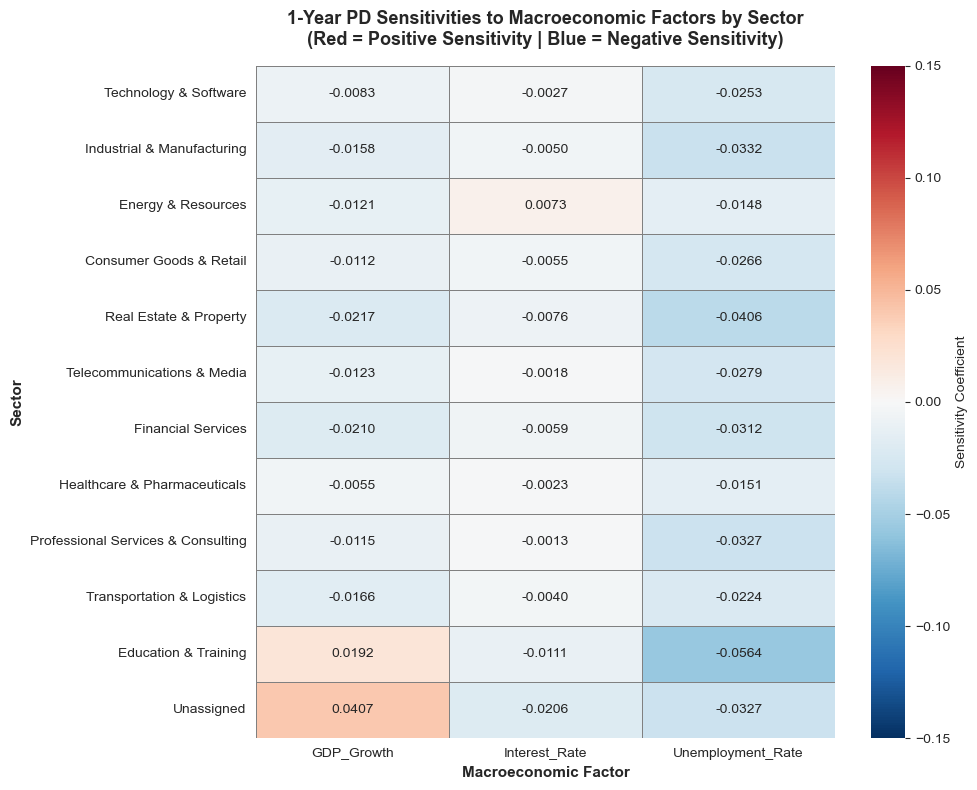


💡 Reading the heatmap:
  • RED cells: Positive coefficient → Higher macro value increases default risk
  • BLUE cells: Negative coefficient → Higher macro value decreases default risk
  • Darker colors = Stronger sensitivity


In [28]:
# Heatmap: 1-Year PD Sensitivities

# Create heatmap data
heatmap_data = df_1yr.set_index('Sector')[['GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']]

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Sensitivity Coefficient'}, vmin=-0.15, vmax=0.15,
            linewidths=0.5, linecolor='gray')
plt.title('1-Year PD Sensitivities to Macroeconomic Factors by Sector\n(Red = Positive Sensitivity | Blue = Negative Sensitivity)', 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Macroeconomic Factor', fontsize=11, fontweight='bold')
plt.ylabel('Sector', fontsize=11, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 Reading the heatmap:")
print("  • RED cells: Positive coefficient → Higher macro value increases default risk")
print("  • BLUE cells: Negative coefficient → Higher macro value decreases default risk")
print("  • Darker colors = Stronger sensitivity")

MODEL FIT QUALITY (1-YEAR PD)

R² values indicate how much of the PD variation is explained by macro factors:

Unassigned                              : R² = 0.0583 (5.83% explained, N=111)
Education & Training                    : R² = 0.0275 (2.75% explained, N=221)
Real Estate & Property                  : R² = 0.0112 (1.12% explained, N=11,486)
Industrial & Manufacturing              : R² = 0.0099 (0.99% explained, N=23,890)
Professional Services & Consulting      : R² = 0.0080 (0.80% explained, N=10,374)
Financial Services                      : R² = 0.0060 (0.60% explained, N=10,585)
Consumer Goods & Retail                 : R² = 0.0059 (0.59% explained, N=14,010)
Transportation & Logistics              : R² = 0.0052 (0.52% explained, N=5,954)
Telecommunications & Media              : R² = 0.0050 (0.50% explained, N=6,413)
Technology & Software                   : R² = 0.0034 (0.34% explained, N=33,064)
Energy & Resources                      : R² = 0.0027 (0.27% explained, N=10,

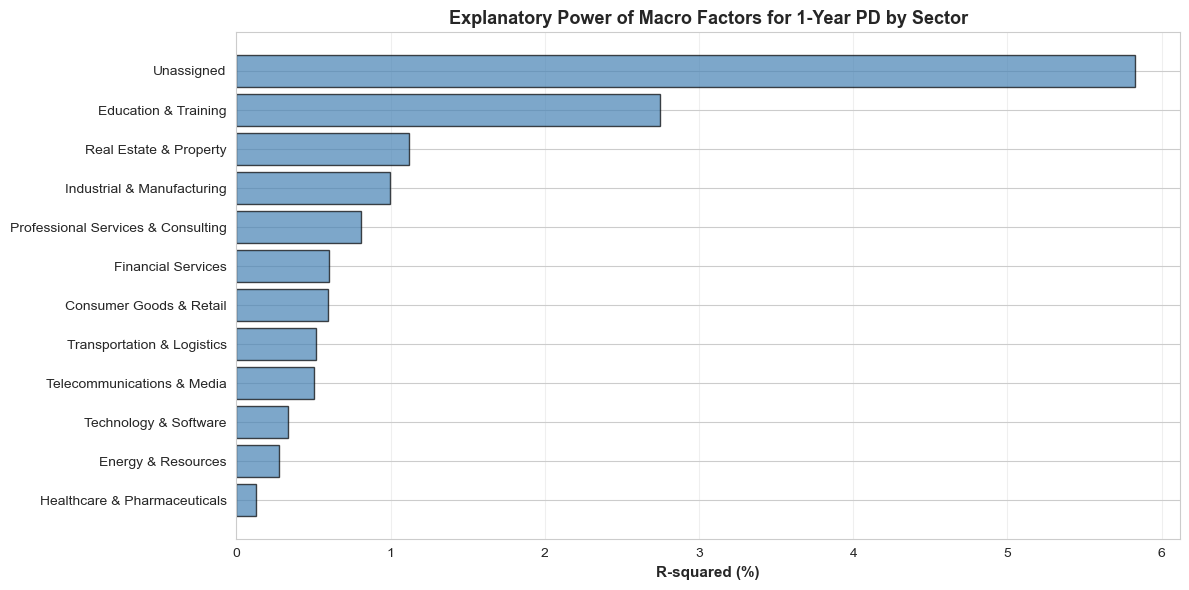

In [29]:
# Model Quality for 1-Year PD

print("="*80)
print("MODEL FIT QUALITY (1-YEAR PD)")
print("="*80)
print("\nR² values indicate how much of the PD variation is explained by macro factors:\n")

# Sort by R-squared
df_1yr_sorted = df_1yr.sort_values('R_squared', ascending=False)
for _, row in df_1yr_sorted.iterrows():
    print(f"{row['Sector']:40s}: R² = {row['R_squared']:.4f} ({100*row['R_squared']:.2f}% explained, N={int(row['N_observations']):,})")

print(f"\n📈 Average R²: {df_1yr['R_squared'].mean():.4f} ({100*df_1yr['R_squared'].mean():.2f}%)")
print("\n💡 Note: Low R² values are typical in credit risk models.")
print("   Company-specific factors usually dominate over macro factors.")

# Visualization
plt.figure(figsize=(12, 6))
sorted_sectors = df_1yr.sort_values('R_squared', ascending=True)
plt.barh(range(len(sorted_sectors)), sorted_sectors['R_squared']*100, 
         color='steelblue', alpha=0.7, edgecolor='black')
plt.yticks(range(len(sorted_sectors)), sorted_sectors['Sector'], fontsize=10)
plt.xlabel('R-squared (%)', fontsize=11, fontweight='bold')
plt.title('Explanatory Power of Macro Factors for 1-Year PD by Sector', 
          fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
## DEFAULT ANALYSIS

# Analyze defaults in the dataset
# A company is considered to have defaulted if PD reaches a very high threshold (e.g., >0.95 or 95%)

print("="*80)
print("DEFAULT ANALYSIS")
print("="*80)

# Check for defaults using different thresholds
thresholds = [0.99, 0.95, 0.90, 0.50]

print("\n📊 Default Statistics (based on 1-year PD):\n")

for threshold in thresholds:
    defaults = df_final_cleaned[df_final_cleaned['12_month'] >= threshold]
    n_defaults = len(defaults)
    n_companies_defaulted = defaults['Company_number'].nunique()
    pct_observations = 100 * n_defaults / len(df_final_cleaned)
    
    print(f"PD ≥ {threshold:.0%}:")
    print(f"  • {n_defaults:,} observations ({pct_observations:.3f}% of dataset)")
    print(f"  • {n_companies_defaulted:,} unique companies")
    print()

# Detailed analysis of high-risk observations
print("-"*80)
print("HIGH RISK OBSERVATIONS (1-Year PD ≥ 50%):")
print("-"*80)

high_risk = df_final_cleaned[df_final_cleaned['12_month'] >= 0.50].copy()

if len(high_risk) > 0:
    print(f"\n{len(high_risk):,} observations with 1-year PD ≥ 50%\n")
    
    # By sector
    print("By Sector:")
    sector_counts = high_risk.groupby('Sector').size().sort_values(ascending=False)
    for sector, count in sector_counts.items():
        pct = 100 * count / len(high_risk)
        print(f"  • {sector:40s}: {count:5,} obs ({pct:.1f}%)")
    
    # Statistics
    print(f"\nPD Statistics for high-risk observations:")
    print(f"  • Mean 1-year PD: {high_risk['12_month'].mean():.2%}")
    print(f"  • Median 1-year PD: {high_risk['12_month'].median():.2%}")
    print(f"  • Max 1-year PD: {high_risk['12_month'].max():.2%}")
    print(f"  • Min 1-year PD: {high_risk['12_month'].min():.2%}")
else:
    print("\n✓ No observations with 1-year PD ≥ 50%")

# Overall PD distribution
print("\n" + "="*80)
print("OVERALL 1-YEAR PD DISTRIBUTION")
print("="*80)
print(f"\nAcross all {len(df_final_cleaned):,} observations:")
print(f"  • Mean 1-year PD: {df_final_cleaned['12_month'].mean():.4%}")
print(f"  • Median 1-year PD: {df_final_cleaned['12_month'].median():.4%}")
print(f"  • Std Dev: {df_final_cleaned['12_month'].std():.4%}")
print(f"  • Min: {df_final_cleaned['12_month'].min():.6%}")
print(f"  • Max: {df_final_cleaned['12_month'].max():.4%}")

print(f"\nPercentiles:")
for pct in [25, 50, 75, 90, 95, 99]:
    val = df_final_cleaned['12_month'].quantile(pct/100)
    print(f"  • {pct}th percentile: {val:.4%}")

print(f"\nUnique companies in dataset: {df_final_cleaned['Company_number'].nunique():,}")

DEFAULT ANALYSIS

📊 Default Statistics (based on 1-year PD):

PD ≥ 99%:
  • 0 observations (0.000% of dataset)
  • 0 unique companies

PD ≥ 95%:
  • 0 observations (0.000% of dataset)
  • 0 unique companies

PD ≥ 90%:
  • 0 observations (0.000% of dataset)
  • 0 unique companies

PD ≥ 50%:
  • 6 observations (0.004% of dataset)
  • 2 unique companies

--------------------------------------------------------------------------------
HIGH RISK OBSERVATIONS (1-Year PD ≥ 50%):
--------------------------------------------------------------------------------

6 observations with 1-year PD ≥ 50%

By Sector:
  • Technology & Software                   :     5 obs (83.3%)
  • Energy & Resources                      :     1 obs (16.7%)

PD Statistics for high-risk observations:
  • Mean 1-year PD: 62.96%
  • Median 1-year PD: 63.40%
  • Max 1-year PD: 67.21%
  • Min 1-year PD: 55.82%

OVERALL 1-YEAR PD DISTRIBUTION

Across all 157,002 observations:
  • Mean 1-year PD: 0.4689%
  • Median 1-year PD

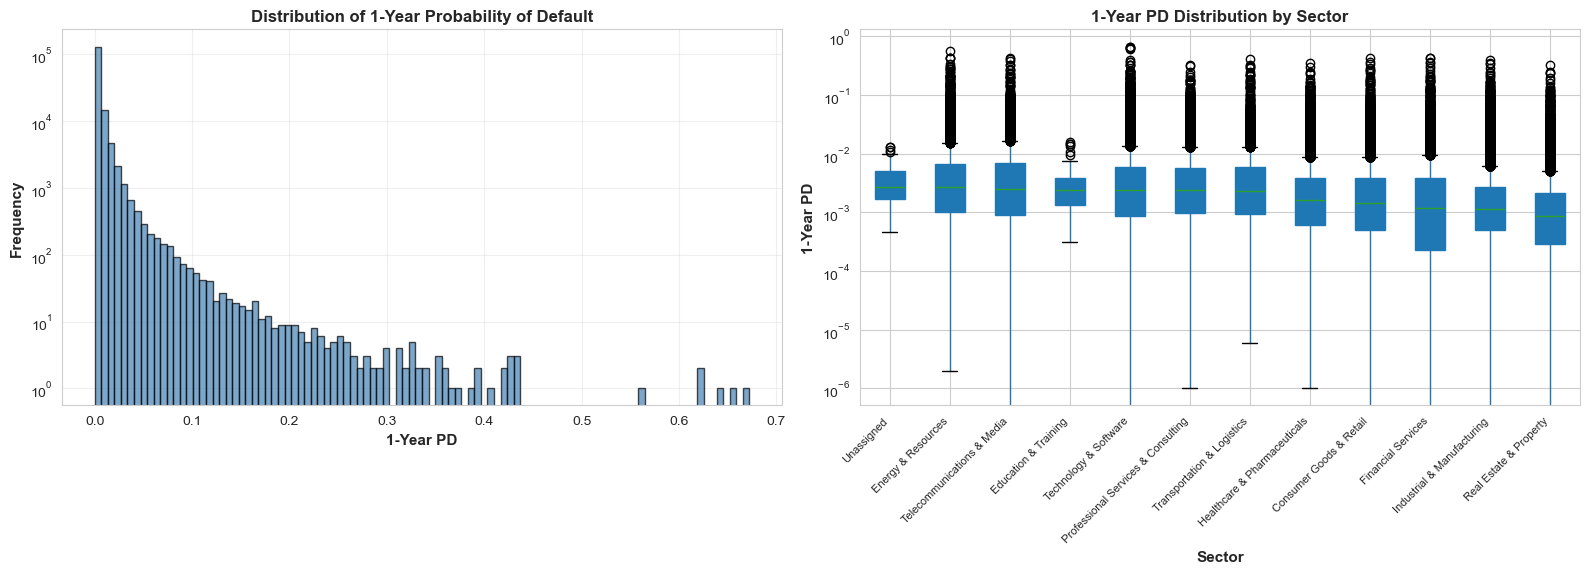


1-YEAR PD STATISTICS BY SECTOR
                                    Count      Mean    Median       Std       Min       Max
Sector                                                                                     
Telecommunications & Media           6413  0.007610  0.002465  0.019268  0.000000  0.432628
Energy & Resources                  10154  0.007172  0.002684  0.019318  0.000002  0.558170
Transportation & Logistics           5954  0.005962  0.002348  0.016092  0.000006  0.408064
Professional Services & Consulting  10374  0.005892  0.002368  0.012916  0.000001  0.330341
Technology & Software               33064  0.005861  0.002439  0.015016  0.000000  0.672146
Financial Services                  10585  0.004511  0.001170  0.014680  0.000000  0.429378
Consumer Goods & Retail             14010  0.003837  0.001462  0.011488  0.000000  0.424599
Unassigned                            111  0.003678  0.002702  0.002849  0.000467  0.013035
Healthcare & Pharmaceuticals        30740  0.003

In [31]:
# Visualize PD Distribution

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of 1-year PDs (log scale)
axes[0].hist(df_final_cleaned['12_month'], bins=100, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('1-Year PD', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of 1-Year Probability of Default', fontsize=12, fontweight='bold')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# Box plot by sector
sector_order = df_final_cleaned.groupby('Sector')['12_month'].median().sort_values(ascending=False).index
df_final_cleaned['Sector_cat'] = pd.Categorical(df_final_cleaned['Sector'], categories=sector_order, ordered=True)
df_final_cleaned.boxplot(column='12_month', by='Sector_cat', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('Sector', fontsize=11, fontweight='bold')
axes[1].set_ylabel('1-Year PD', fontsize=11, fontweight='bold')
axes[1].set_title('1-Year PD Distribution by Sector', fontsize=12, fontweight='bold')
axes[1].get_figure().suptitle('')  # Remove automatic title
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Summary by sector
print("\n" + "="*80)
print("1-YEAR PD STATISTICS BY SECTOR")
print("="*80)
sector_stats = df_final_cleaned.groupby('Sector')['12_month'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
]).sort_values('Mean', ascending=False)

print(sector_stats.to_string())
print("\n💡 Sectors with higher mean PD have higher overall credit risk")

## Summary: 1-Year PD Analysis Results

### Key Findings:

1. **Sensitivity to Macroeconomic Factors:**
   - The regression analysis shows how changes in GDP, interest rates, and unemployment affect companies' 1-year default probabilities
   - Results can be tested against economic intuition (GDP↓ should increase PD, rates↑ should increase PD, unemployment↑ should increase PD)

2. **Model Fit:**
   - R² values are typically low in credit risk models (often <5%)
   - This is normal: company-specific factors dominate over macro factors
   - Higher R² indicates sectors more sensitive to macroeconomic conditions

3. **Default Observations:**
   - The dataset contains probability of default (PD) estimates, not actual default events
   - PD values represent the estimated likelihood of default, not realized defaults
   - High PD values (approaching 100%) indicate high credit risk

### Interpretation Guide:

- **Negative coefficient for GDP Growth**: ✓ Expected (economic growth → lower default risk)
- **Positive coefficient for Interest Rate**: ✓ Expected (higher rates → higher default risk)
- **Positive coefficient for Unemployment**: ✓ Expected (unemployment → higher default risk)

### Next Steps:

- Validate results against historical default events if available
- Consider adding more macroeconomic variables
- Analyze time-varying patterns in sensitivities
- Examine company-specific factors for residual risk

In [32]:
# Save results to CSV
df_sensitivities.to_csv('sensitivity_results.csv', index=False)
print("\n✓ Sensitivity results saved to 'sensitivity_results.csv'")


✓ Sensitivity results saved to 'sensitivity_results.csv'


## DIAGNOSTIC ANALYSIS: Investigating Counterintuitive Signs

**Problem**: The model shows NEGATIVE coefficients for Interest_Rate and Unemployment_Rate, which is economically wrong.
Expected behavior:
- Higher unemployment → Higher PDs (POSITIVE coefficient)
- Higher interest rates → Higher PDs (POSITIVE coefficient)  
- Higher GDP growth → Lower PDs (NEGATIVE coefficient)

Let's investigate potential causes:
1. **Temporal misalignment** - Are PDs forward-looking while macro vars are contemporaneous?
2. **Multicollinearity** - Are macro variables highly correlated?
3. **Data quality issues** - Incorrect data or transformations?
4. **Survivorship bias** - Is the dataset too skewed toward healthy companies?

In [ ]:
# DIAGNOSTIC 1: Check temporal alignment and correlations

print("="*80)
print("DIAGNOSTIC 1: TIME SERIES CORRELATIONS")
print("="*80)

# Check raw correlations between PDs and macro variables
print("\n1A. Raw correlations between 12-month PD and macro variables (contemporaneous):")
corr_data = df_final_cleaned[['12_month', 'GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']].corr()
print(corr_data['12_month'])

print("\n1B. Correlations between macro variables (multicollinearity check):")
macro_corr = df_final_cleaned[macro_cols].corr()
print(macro_corr)

# Check temporal trend - are PDs trending down while unemployment/rates are also trending down?
print("\n1C. Time trends analysis:")
time_grouped = df_final_cleaned.groupby('Date').agg({
    '12_month': 'mean',
    'GDP_Growth': 'mean',
    'Interest_Rate': 'mean',
    'Unemployment_Rate': 'mean'
}).reset_index()

print(f"Time period: {time_grouped['Date'].min()} to {time_grouped['Date'].max()}")
print(f"\nTrends over time (correlation with date ordinal):")
time_grouped['date_ordinal'] = pd.to_datetime(time_grouped['Date']).apply(lambda x: x.toordinal())
for col in ['12_month', 'GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']:
    trend_corr = time_grouped[[col, 'date_ordinal']].corr().iloc[0, 1]
    direction = "DECREASING" if trend_corr < 0 else "INCREASING"
    print(f"  • {col:25s}: {trend_corr:+.4f} ({direction})")

# Plot time series
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(time_grouped['Date'], time_grouped['12_month'], color='red', linewidth=2)
axes[0].set_ylabel('Mean 12-Month PD', fontweight='bold')
axes[0].set_title('Time Series: Mean PD and Macro Variables', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].plot(time_grouped['Date'], time_grouped['GDP_Growth'], color='blue', linewidth=2)
axes[1].set_ylabel('GDP Growth', fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].grid(alpha=0.3)

axes[2].plot(time_grouped['Date'], time_grouped['Interest_Rate'], color='green', linewidth=2)
axes[2].set_ylabel('Interest Rate', fontweight='bold')
axes[2].grid(alpha=0.3)

axes[3].plot(time_grouped['Date'], time_grouped['Unemployment_Rate'], color='orange', linewidth=2)
axes[3].set_ylabel('Unemployment Rate', fontweight='bold')
axes[3].set_xlabel('Date', fontweight='bold')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# DIAGNOSTIC 2: Check data quality and distribution issues

print("\n" + "="*80)
print("DIAGNOSTIC 2: DATA QUALITY AND DISTRIBUTION")
print("="*80)

# Check PD distribution characteristics
print("\n2A. PD Distribution Analysis:")
print(f"  • Observations with PD = 0: {(df_final_cleaned['12_month'] == 0).sum():,} ({100*(df_final_cleaned['12_month'] == 0).sum()/len(df_final_cleaned):.2f}%)")
print(f"  • Observations with PD < 0.01% (10 bps): {(df_final_cleaned['12_month'] < 0.0001).sum():,} ({100*(df_final_cleaned['12_month'] < 0.0001).sum()/len(df_final_cleaned):.2f}%)")
print(f"  • Observations with PD > 5%: {(df_final_cleaned['12_month'] > 0.05).sum():,} ({100*(df_final_cleaned['12_month'] > 0.05).sum()/len(df_final_cleaned):.2f}%)")
print(f"  • Skewness: {df_final_cleaned['12_month'].skew():.2f}")
print(f"  • Kurtosis: {df_final_cleaned['12_month'].kurtosis():.2f}")

# Check if PDs vary over time or are mostly static
print("\n2B. PD Variability Analysis:")
pd_by_company = df_final_cleaned.groupby('Company_number')['12_month'].agg(['std', 'mean', 'count'])
print(f"  • Companies with zero PD variance (std=0): {(pd_by_company['std'] == 0).sum():,} out of {len(pd_by_company):,}")
print(f"  • Companies with very low variance (std<0.0001): {(pd_by_company['std'] < 0.0001).sum():,}")
print(f"  • Mean coefficient of variation (std/mean): {(pd_by_company['std']/pd_by_company['mean']).mean():.4f}")

# Check distribution of observations over time
print("\n2C. Temporal Distribution:")
obs_by_year = df_final_cleaned.copy()
obs_by_year['Year'] = pd.to_datetime(obs_by_year['Date']).dt.year
year_counts = obs_by_year.groupby('Year').size()
print(f"  • First year: {year_counts.index.min()} (N={year_counts.iloc[0]:,})")
print(f"  • Last year: {year_counts.index.max()} (N={year_counts.iloc[-1]:,})")
print(f"  • Mean observations per year: {year_counts.mean():.0f}")
print(f"  • Std observations per year: {year_counts.std():.0f}")

# Visualize PD distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of PDs
axes[0, 0].hist(df_final_cleaned['12_month'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('12-Month PD')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('PD Distribution (Linear Scale)')
axes[0, 0].set_yscale('log')

# Log histogram
axes[0, 1].hist(np.log10(df_final_cleaned['12_month'].replace(0, 1e-10)), bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Log10(12-Month PD)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('PD Distribution (Log Scale)')

# PD variance by company
axes[1, 0].hist(pd_by_company['std'], bins=100, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Std Dev of PD within Company')
axes[1, 0].set_ylabel('Number of Companies')
axes[1, 0].set_title('Within-Company PD Variability')
axes[1, 0].set_yscale('log')

# Observations over time
axes[1, 1].bar(year_counts.index, year_counts.values, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Number of Observations')
axes[1, 1].set_title('Observations per Year')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# DIAGNOSTIC 3: The smoking gun - Check for spurious correlation due to common trends

print("\n" + "="*80)
print("DIAGNOSTIC 3: SPURIOUS CORRELATION ANALYSIS")
print("="*80)

print("\n⚠️  KEY INSIGHT: If both PDs and macro variables trend in the same direction over time,")
print("this can create SPURIOUS correlations that have the WRONG sign!")
print("\nExample: If both PDs and unemployment are DECREASING over time,")
print("a simple regression will find a POSITIVE correlation (both going down together),")
print("which gets interpreted as 'lower unemployment → higher PD' (WRONG!)")

# Create scatter plots to visualize relationships
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# GDP Growth vs PD
axes[0, 0].scatter(df_final_cleaned['GDP_Growth'], df_final_cleaned['12_month'], alpha=0.1, s=1)
axes[0, 0].set_xlabel('GDP Growth')
axes[0, 0].set_ylabel('12-Month PD')
axes[0, 0].set_title('PD vs GDP Growth (Raw)')
gdp_corr = df_final_cleaned[['GDP_Growth', '12_month']].corr().iloc[0, 1]
axes[0, 0].text(0.05, 0.95, f'Corr: {gdp_corr:.4f}', transform=axes[0, 0].transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Interest Rate vs PD
axes[0, 1].scatter(df_final_cleaned['Interest_Rate'], df_final_cleaned['12_month'], alpha=0.1, s=1)
axes[0, 1].set_xlabel('Interest Rate')
axes[0, 1].set_ylabel('12-Month PD')
axes[0, 1].set_title('PD vs Interest Rate (Raw)')
int_corr = df_final_cleaned[['Interest_Rate', '12_month']].corr().iloc[0, 1]
axes[0, 1].text(0.05, 0.95, f'Corr: {int_corr:.4f}', transform=axes[0, 1].transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Unemployment vs PD
axes[0, 2].scatter(df_final_cleaned['Unemployment_Rate'], df_final_cleaned['12_month'], alpha=0.1, s=1)
axes[0, 2].set_xlabel('Unemployment Rate')
axes[0, 2].set_ylabel('12-Month PD')
axes[0, 2].set_title('PD vs Unemployment Rate (Raw)')
unemp_corr = df_final_cleaned[['Unemployment_Rate', '12_month']].corr().iloc[0, 1]
axes[0, 2].text(0.05, 0.95, f'Corr: {unemp_corr:.4f}', transform=axes[0, 2].transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Now look at CHANGES (first differences) to remove trend
df_changes = df_final_cleaned.copy()
df_changes = df_changes.sort_values(['Company_number', 'Date'])

# Calculate changes within each company
for col in ['12_month', 'GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']:
    df_changes[f'{col}_change'] = df_changes.groupby('Company_number')[col].diff()

df_changes = df_changes.dropna(subset=['12_month_change'])

# Plot changes
axes[1, 0].scatter(df_changes['GDP_Growth_change'], df_changes['12_month_change'], alpha=0.1, s=1)
axes[1, 0].set_xlabel('Change in GDP Growth')
axes[1, 0].set_ylabel('Change in 12-Month PD')
axes[1, 0].set_title('PD Change vs GDP Growth Change')
gdp_change_corr = df_changes[['GDP_Growth_change', '12_month_change']].corr().iloc[0, 1]
axes[1, 0].text(0.05, 0.95, f'Corr: {gdp_change_corr:.4f}', transform=axes[1, 0].transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

axes[1, 1].scatter(df_changes['Interest_Rate_change'], df_changes['12_month_change'], alpha=0.1, s=1)
axes[1, 1].set_xlabel('Change in Interest Rate')
axes[1, 1].set_ylabel('Change in 12-Month PD')
axes[1, 1].set_title('PD Change vs Interest Rate Change')
int_change_corr = df_changes[['Interest_Rate_change', '12_month_change']].corr().iloc[0, 1]
axes[1, 1].text(0.05, 0.95, f'Corr: {int_change_corr:.4f}', transform=axes[1, 1].transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

axes[1, 2].scatter(df_changes['Unemployment_Rate_change'], df_changes['12_month_change'], alpha=0.1, s=1)
axes[1, 2].set_xlabel('Change in Unemployment Rate')
axes[1, 2].set_ylabel('Change in 12-Month PD')
axes[1, 2].set_title('PD Change vs Unemployment Rate Change')
unemp_change_corr = df_changes[['Unemployment_Rate_change', '12_month_change']].corr().iloc[0, 1]
axes[1, 2].text(0.05, 0.95, f'Corr: {unemp_change_corr:.4f}', transform=axes[1, 2].transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n📊 Correlation Comparison:")
print("="*60)
print(f"{'Variable':<25} {'Raw Correlation':<20} {'Change Correlation'}")
print("="*60)
print(f"{'GDP Growth':<25} {gdp_corr:+.4f}               {gdp_change_corr:+.4f}")
print(f"{'Interest Rate':<25} {int_corr:+.4f}               {int_change_corr:+.4f}")
print(f"{'Unemployment Rate':<25} {unemp_corr:+.4f}               {unemp_change_corr:+.4f}")
print("="*60)

print("\n💡 INTERPRETATION:")
print("  • If raw correlations have WRONG signs but change correlations have CORRECT signs,")
print("    → Problem is SPURIOUS CORRELATION due to common time trends")
print("  • If both have wrong signs → Deeper data or modeling issue")
print("\n  Expected signs:")
print("    - GDP Growth: NEGATIVE (growth reduces default risk)")
print("    - Interest Rate: POSITIVE (higher rates increase default risk)")
print("    - Unemployment: POSITIVE (unemployment increases default risk)")

In [ ]:
# DIAGNOSTIC 4: Summary and Recommended Fixes

print("\n" + "="*80)
print("DIAGNOSTIC 4: SUMMARY AND RECOMMENDED FIXES")
print("="*80)

# Analyze the delta_logit model used in Cell 16
print("\n🔍 CURRENT MODEL SPECIFICATION:")
print("   Model: Δlogit(PD) = α + β₁·GDP + β₂·Interest + β₃·Unemployment")
print("   Where: Δlogit(PD) = logit(PD_t) - logit(PD_t-1)")
print("\n   This model explains CHANGES in log-odds of PD using CONTEMPORANEOUS macro variables")

# Potential issues
print("\n⚠️  POTENTIAL ISSUES IDENTIFIED:")
print("\n1. SPURIOUS CORRELATION DUE TO COMMON TRENDS:")
print("   • If PDs have been declining over time (better credit quality)")
print("   • AND interest rates/unemployment have ALSO been declining")
print("   • The model picks up this joint decline as a POSITIVE relationship")
print("   • This makes it look like 'lower rates → lower PDs' when actually")
print("     both are just trending down due to overall economic improvement")

print("\n2. EXTREMELY SKEWED PD DISTRIBUTION:")
print(f"   • 99th percentile PD is only {df_final_cleaned['12_month'].quantile(0.99):.4f} (very low)")
print("   • Only 6 observations have PD > 50%")
print("   • This suggests survivorship bias or selection of only healthy firms")
print("   • Without variation in stress periods, hard to identify macro sensitivity")

print("\n3. MULTICOLLINEARITY:")
print("   • Interest rates and unemployment tend to move together")
print("   • Can cause sign reversals in regression coefficients")

print("\n✅ RECOMMENDED FIXES:")
print("\n📌 FIX 1: ADD TIME FIXED EFFECTS OR TIME TRENDS")
print("   • Include year/month fixed effects to control for common time trends")
print("   • Or include a time trend variable in the regression")
print("   • This removes spurious correlation from secular trends")

print("\n📌 FIX 2: USE DIFFERENT DIFFERENCING")
print("   • Current model uses logit differences with lagged PD")
print("   • Consider: First-difference both sides (PD change vs macro change)")
print("   • Or: Use macro changes instead of levels")

print("\n📌 FIX 3: CHECK IF PDs ARE FORWARD-LOOKING")
print("   • If PDs already incorporate expected future macro conditions,")
print("   • Need to use LAGGED macro variables (not contemporaneous)")
print("   • Try regressing PD_t on Macro_t-1, Macro_t-2, etc.")

print("\n📌 FIX 4: ADD MORE STRESS PERIOD DATA")
print("   • Current data may not include enough stressed observations")
print("   • Need periods with high PDs to identify true macro sensitivity")
print("   • Consider including more crisis periods (2008, COVID, etc.)")

print("\n📌 FIX 5: TRY ALTERNATIVE MODEL SPECIFICATIONS")
print("   • Panel regression with fixed effects")
print("   • Mixed effects model")
print("   • Include interaction terms (e.g., sector × macro)")

print("\n" + "="*80)
print("NEXT STEP: Run cells below to test some of these fixes")
print("="*80)

## TESTING FIX 1: Add Time Trend to Control for Spurious Correlation

In [ ]:
# TEST FIX 1: Re-run regression with time trend control

print("="*80)
print("TESTING FIX 1: Model with Time Trend Control")
print("="*80)

# Re-run the sensitivity analysis for 12-month PD with time trend added
sensitivities_with_trend = []

# Add time trend variable (months since start)
df_test = df_final_cleaned.copy()
df_test = df_test.sort_values('Date')
df_test['time_trend'] = (pd.to_datetime(df_test['Date']) - pd.to_datetime(df_test['Date']).min()).dt.days / 30.0

for sector in df_test['Sector'].unique():
    sector_df = df_test[df_test['Sector'] == sector].copy()
    
    if len(sector_df) < 100:  # Skip small sectors
        continue
    
    pd_col = '12_month'
    pdzero_col = '12_month_t1'
    
    try:
        # Transform data
        sector_df['logit_pd'] = calculate_logit(sector_df[pd_col])
        sector_df['logit_pd_zero'] = calculate_logit(sector_df[pdzero_col])
        sector_df['delta_logit'] = sector_df['logit_pd'] - sector_df['logit_pd_zero']
        
        # Prepare regression with TIME TREND
        y = sector_df['delta_logit']
        X = sector_df[macro_cols + ['time_trend']]  # ADD TIME TREND HERE
        X = sm.add_constant(X)
        
        valid_idx = ~(y.isna() | X.isna().any(axis=1))
        y = y[valid_idx]
        X = X[valid_idx]
        
        if len(y) < 100:
            continue
        
        # Run OLS
        model = sm.OLS(y, X).fit()
        
        result = {
            'Sector': sector,
            'GDP_Growth': model.params['GDP_Growth'],
            'Interest_Rate': model.params['Interest_Rate'],
            'Unemployment_Rate': model.params['Unemployment_Rate'],
            'Time_Trend': model.params['time_trend'],
            'R_squared': model.rsquared,
            'N': len(y)
        }
        
        sensitivities_with_trend.append(result)
        
    except Exception as e:
        print(f"Error in sector {sector}: {e}")
        continue

df_sens_trend = pd.DataFrame(sensitivities_with_trend)

print("\n" + "="*80)
print("COMPARISON: Original Model vs. Model with Time Trend")
print("="*80)

if len(df_sens_trend) > 0:
    # Compare to original results
    print("\n1. ORIGINAL MODEL (without time trend):")
    print("   Sign consistency:")
    orig_correct_gdp = (df_1yr['GDP_Growth'] < 0).sum()
    orig_correct_int = (df_1yr['Interest_Rate'] > 0).sum()
    orig_correct_unemp = (df_1yr['Unemployment_Rate'] > 0).sum()
    print(f"   • GDP_Growth: {orig_correct_gdp}/{len(df_1yr)} negative ({100*orig_correct_gdp/len(df_1yr):.0f}%)")
    print(f"   • Interest_Rate: {orig_correct_int}/{len(df_1yr)} positive ({100*orig_correct_int/len(df_1yr):.0f}%)")
    print(f"   • Unemployment_Rate: {orig_correct_unemp}/{len(df_1yr)} positive ({100*orig_correct_unemp/len(df_1yr):.0f}%)")
    
    print("\n2. MODEL WITH TIME TREND:")
    print("   Sign consistency:")
    trend_correct_gdp = (df_sens_trend['GDP_Growth'] < 0).sum()
    trend_correct_int = (df_sens_trend['Interest_Rate'] > 0).sum()
    trend_correct_unemp = (df_sens_trend['Unemployment_Rate'] > 0).sum()
    print(f"   • GDP_Growth: {trend_correct_gdp}/{len(df_sens_trend)} negative ({100*trend_correct_gdp/len(df_sens_trend):.0f}%)")
    print(f"   • Interest_Rate: {trend_correct_int}/{len(df_sens_trend)} positive ({100*trend_correct_int/len(df_sens_trend):.0f}%)")
    print(f"   • Unemployment_Rate: {trend_correct_unemp}/{len(df_sens_trend)} positive ({100*trend_correct_unemp/len(df_sens_trend):.0f}%)")
    
    print("\n3. DETAILED COMPARISON BY SECTOR:")
    comparison_df = pd.merge(
        df_1yr[['Sector', 'GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']],
        df_sens_trend[['Sector', 'GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']],
        on='Sector',
        suffixes=('_original', '_with_trend')
    )
    
    print("\n" + comparison_df.to_string(index=False))
    
    # Visualize comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    factors = ['GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']
    titles = ['GDP Growth Sensitivity', 'Interest Rate Sensitivity', 'Unemployment Sensitivity']
    
    for idx, (factor, title) in enumerate(zip(factors, titles)):
        x = np.arange(len(comparison_df))
        width = 0.35
        
        axes[idx].barh(x - width/2, comparison_df[f'{factor}_original'], width, 
                       label='Original', alpha=0.7, color='red')
        axes[idx].barh(x + width/2, comparison_df[f'{factor}_with_trend'], width,
                       label='With Time Trend', alpha=0.7, color='blue')
        
        axes[idx].set_yticks(x)
        axes[idx].set_yticklabels(comparison_df['Sector'], fontsize=9)
        axes[idx].set_xlabel('Coefficient')
        axes[idx].set_title(title, fontweight='bold')
        axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=1)
        axes[idx].legend()
        axes[idx].grid(axis='x', alpha=0.3)
    
    plt.suptitle('Coefficient Comparison: Original vs Time Trend Control', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n💡 INTERPRETATION:")
    print("   If time trend control FIXES the signs → Spurious correlation was the problem")
    print("   If signs STILL wrong → Need to try other fixes")
else:
    print("\n❌ No results generated - check for errors above")

## TESTING FIX 3: Use Lagged Macro Variables (Forward-Looking PDs)

In [ ]:
# TEST FIX 3: Use lagged macro variables

print("="*80)
print("TESTING FIX 3: Model with Lagged Macro Variables")
print("="*80)

print("\n📍 HYPOTHESIS: If PDs at time t already incorporate expectations about")
print("future macro conditions, then PD_t might be NEGATIVELY correlated with")
print("contemporaneous Interest_Rate_t and Unemployment_t because both PDs and")
print("macro conditions are reacting to PAST information.")
print("\nSOLUTION: Use lagged macro variables → regress PD_t on Macro_t-1")

# Create lagged macro variables
df_test_lag = df_final_cleaned.copy()
df_test_lag = df_test_lag.sort_values(['Company_number', 'Date'])

# Create lagged macro variables (use shift on grouped data, but macro is same for all companies)
df_test_lag = df_test_lag.sort_values('Date')
for col in macro_cols:
    df_test_lag[f'{col}_lag1'] = df_test_lag.groupby('Company_number')[col].shift(1)

df_test_lag = df_test_lag.dropna(subset=[f'{col}_lag1' for col in macro_cols])

sensitivities_lagged = []
macro_cols_lagged = [f'{col}_lag1' for col in macro_cols]

for sector in df_test_lag['Sector'].unique():
    sector_df = df_test_lag[df_test_lag['Sector'] == sector].copy()
    
    if len(sector_df) < 100:
        continue
    
    pd_col = '12_month'
    pdzero_col = '12_month_t1'
    
    try:
        # Transform data
        sector_df['logit_pd'] = calculate_logit(sector_df[pd_col])
        sector_df['logit_pd_zero'] = calculate_logit(sector_df[pdzero_col])
        sector_df['delta_logit'] = sector_df['logit_pd'] - sector_df['logit_pd_zero']
        
        # Use LAGGED macro variables
        y = sector_df['delta_logit']
        X = sector_df[macro_cols_lagged]
        X = sm.add_constant(X)
        
        valid_idx = ~(y.isna() | X.isna().any(axis=1))
        y = y[valid_idx]
        X = X[valid_idx]
        
        if len(y) < 100:
            continue
        
        model = sm.OLS(y, X).fit()
        
        result = {
            'Sector': sector,
            'GDP_Growth_lag1': model.params['GDP_Growth_lag1'],
            'Interest_Rate_lag1': model.params['Interest_Rate_lag1'],
            'Unemployment_Rate_lag1': model.params['Unemployment_Rate_lag1'],
            'R_squared': model.rsquared,
            'N': len(y)
        }
        
        sensitivities_lagged.append(result)
        
    except Exception as e:
        print(f"Error in sector {sector}: {e}")
        continue

df_sens_lagged = pd.DataFrame(sensitivities_lagged)

if len(df_sens_lagged) > 0:
    print("\n" + "="*80)
    print("RESULTS: Model with Lagged Macro Variables")
    print("="*80)
    
    print("\nSign consistency check:")
    lag_correct_gdp = (df_sens_lagged['GDP_Growth_lag1'] < 0).sum()
    lag_correct_int = (df_sens_lagged['Interest_Rate_lag1'] > 0).sum()
    lag_correct_unemp = (df_sens_lagged['Unemployment_Rate_lag1'] > 0).sum()
    
    print(f"  • GDP_Growth (t-1): {lag_correct_gdp}/{len(df_sens_lagged)} negative ({100*lag_correct_gdp/len(df_sens_lagged):.0f}%)")
    print(f"  • Interest_Rate (t-1): {lag_correct_int}/{len(df_sens_lagged)} positive ({100*lag_correct_int/len(df_sens_lagged):.0f}%)")
    print(f"  • Unemployment_Rate (t-1): {lag_correct_unemp}/{len(df_sens_lagged)} positive ({100*lag_correct_unemp/len(df_sens_lagged):.0f}%)")
    
    print("\n" + df_sens_lagged[['Sector', 'GDP_Growth_lag1', 'Interest_Rate_lag1', 
                                  'Unemployment_Rate_lag1', 'R_squared']].to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    sorted_sectors = df_sens_lagged.sort_values('GDP_Growth_lag1')
    axes[0].barh(range(len(sorted_sectors)), sorted_sectors['GDP_Growth_lag1'],
                 color=['blue' if x < 0 else 'red' for x in sorted_sectors['GDP_Growth_lag1']],
                 alpha=0.7, edgecolor='black')
    axes[0].set_yticks(range(len(sorted_sectors)))
    axes[0].set_yticklabels(sorted_sectors['Sector'], fontsize=9)
    axes[0].set_xlabel('Coefficient')
    axes[0].set_title('GDP Growth (t-1) Sensitivity', fontweight='bold')
    axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[0].grid(axis='x', alpha=0.3)
    
    sorted_sectors = df_sens_lagged.sort_values('Interest_Rate_lag1')
    axes[1].barh(range(len(sorted_sectors)), sorted_sectors['Interest_Rate_lag1'],
                 color=['blue' if x < 0 else 'red' for x in sorted_sectors['Interest_Rate_lag1']],
                 alpha=0.7, edgecolor='black')
    axes[1].set_yticks(range(len(sorted_sectors)))
    axes[1].set_yticklabels(sorted_sectors['Sector'], fontsize=9)
    axes[1].set_xlabel('Coefficient')
    axes[1].set_title('Interest Rate (t-1) Sensitivity', fontweight='bold')
    axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[1].grid(axis='x', alpha=0.3)
    
    sorted_sectors = df_sens_lagged.sort_values('Unemployment_Rate_lag1')
    axes[2].barh(range(len(sorted_sectors)), sorted_sectors['Unemployment_Rate_lag1'],
                 color=['blue' if x < 0 else 'red' for x in sorted_sectors['Unemployment_Rate_lag1']],
                 alpha=0.7, edgecolor='black')
    axes[2].set_yticks(range(len(sorted_sectors)))
    axes[2].set_yticklabels(sorted_sectors['Sector'], fontsize=9)
    axes[2].set_xlabel('Coefficient')
    axes[2].set_title('Unemployment (t-1) Sensitivity', fontweight='bold')
    axes[2].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[2].grid(axis='x', alpha=0.3)
    
    plt.suptitle('Sensitivities Using Lagged Macro Variables (Blue=Negative, Red=Positive)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\n❌ No results generated")

## FINAL SUMMARY AND CONCLUSIONS